<a href="https://colab.research.google.com/github/Animeshupgrade/21-Days-21-ML-projects/blob/main/Predicting_housing_market_tends_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Import the libraries***

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn .linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import xgboost as xgb
import os

sns.set_style("darkgrid")

**Step 2:Data loading via kaggle API**

In [6]:
# Install the Kaggle library
!pip install -q kaggle

# Use Colab's file uploader
from google.colab import files
print("Please upload the kaggle.json file you downloaded from your Kaggle account.")
files.upload()

# Create a directory for the Kaggle API configuration
!mkdir -p ~/.kaggle
# Move the uploaded kaggle.json to the required directory
!cp kaggle.json ~/.kaggle/
# Set the correct permissions for the file
!chmod 600 ~/.kaggle/kaggle.json

print("\nKaggle API configured successfully.")

Please upload the kaggle.json file you downloaded from your Kaggle account.


Saving kaggle.json to kaggle (1).json

Kaggle API configured successfully.


In [7]:
# Download the dataset from the 'house-prices-advanced-regression-techniques' competition
!kaggle competitions download -c house-prices-advanced-regression-techniques

# Unzip the downloaded files
!unzip -o house-prices-advanced-regression-techniques.zip

print("\nDataset downloaded and unzipped.")

house-prices-advanced-regression-techniques.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  house-prices-advanced-regression-techniques.zip
  inflating: data_description.txt    
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               

Dataset downloaded and unzipped.


In [8]:
# Now, load the data from the unzipped CSV files
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# Set the 'Id' column as the index for consistency
train_df.set_index('Id', inplace=True)
test_df.set_index('Id', inplace=True)

print(f"Training data shape: {train_df.shape}")
print(f"Testing data shape: {test_df.shape}")

print("Data loaded successfully:")
train_df.head()

Training data shape: (1460, 80)
Testing data shape: (1459, 79)
Data loaded successfully:


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# Step3: **Deep dive onto the EDA On the target variable(SalesPrice)**

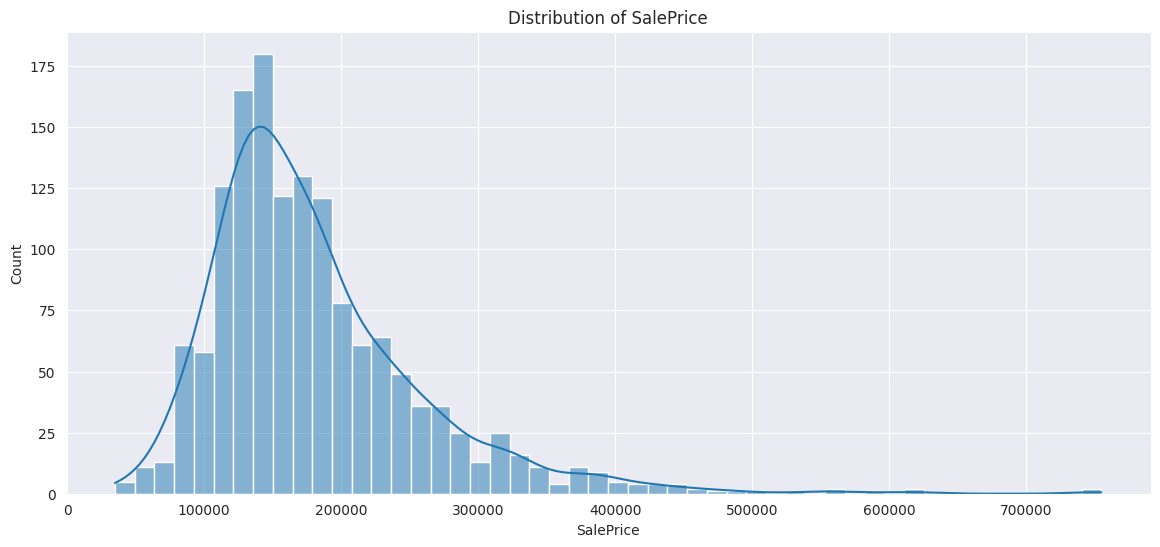

skewness of SalePrice is 1.8828757597682129


In [9]:
plt.figure(figsize=(14,6))
sns.histplot(train_df['SalePrice'],kde=True,bins =50)
plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.show()

print(f"skewness of SalePrice is {train_df['SalePrice'].skew()}")

**# Observation:** This plot is right skewed(positively skewed).That can negetively hampered the model's performance. The model often assumes that the variables normally distributed.

In [10]:
# To fix this use the log transformation

print(np.log(10))
print(np.log(100000))
print(np.log(1000000000000))

2.302585092994046
11.512925464970229
27.631021115928547


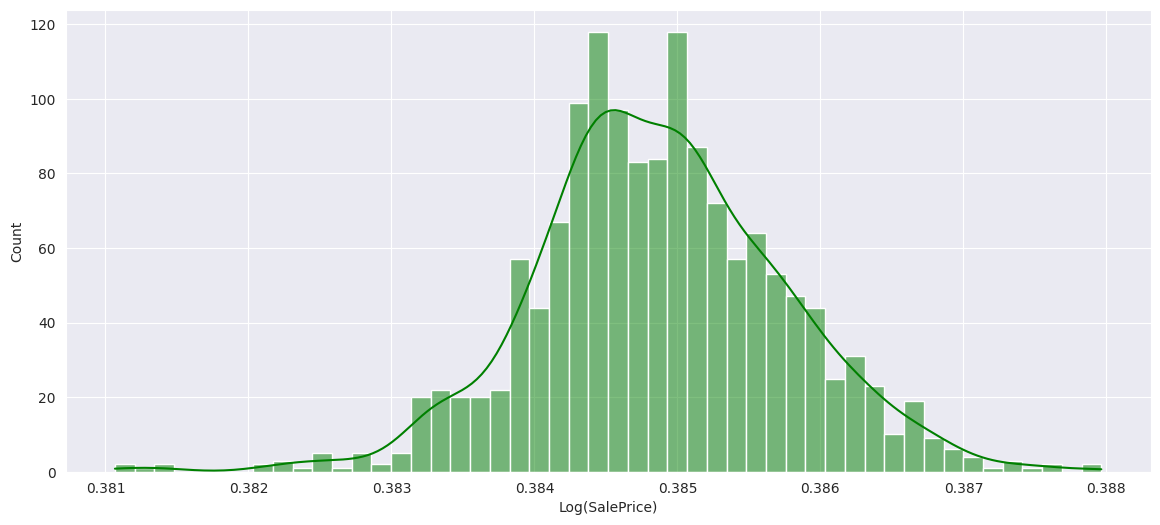

skewness of log-Transformed SalePrice is -0.08206873723446366


In [25]:
train_df['SalePrice'] = np.log1p(train_df['SalePrice'])

plt.figure(figsize=(14,6))
sns.histplot(train_df['SalePrice'],kde = True,bins=50,color='green')
plt.title = "Distribution of log-Transformed SalePrice"
plt.xlabel("Log(SalePrice)")
plt.show()

print(f"skewness of log-Transformed SalePrice is {train_df['SalePrice'].skew()}")

**# Observation:** After the log Transformation teh distribution for the SalePrice remain much closer to and normally distributed.

# **Step 4:**Feature Variable(EDA)

Index(['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
       'TotalBsmtSF', 'FullBath', '1stFlrSF', 'YearBuilt', 'YearRemodAdd'],
      dtype='object')


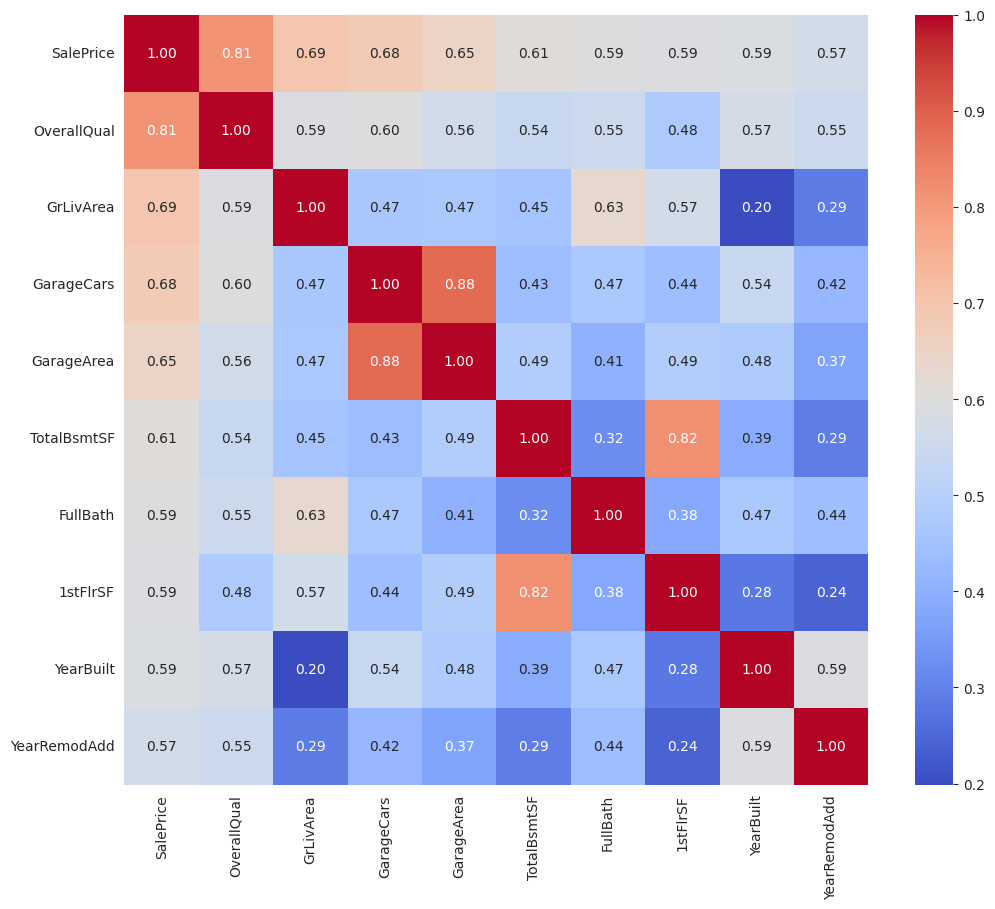

In [26]:
# Finding out the top correlated features of target variables
corrmat = train_df.corr(numeric_only=True)
top_corr_features = corrmat.nlargest(10,'SalePrice')['SalePrice'].index
top_corr_mat = train_df[top_corr_features].corr()
print(top_corr_features)

plt.figure(figsize=(12, 10))
sns.heatmap(top_corr_mat, annot=True, cmap='coolwarm', fmt='.2f')
plt.title= "Correlation Matrix of Top 10 Features with SalePrice"
plt.show()

**# Insight:** The heatmap shows that `OverallQual` (Overall Quality), `GrLivArea` (Above Ground Living Area), and `GarageCars`/`GarageArea` are the most positively correlated features with `SalePrice`. This makes intuitive sense—better quality, larger houses with bigger garages tend to be more expensive.

**# Step 5:** Data Preprocessing & Feture Engineering

In [27]:
# Combine train and test data for consistent preprocessing

# Combine train and test data for consistent preprocessing
all_data = pd.concat((train_df.loc[:,:'SaleCondition'],
                      test_df.loc[:,:'SaleCondition']))

print(f"Combined data shape: {all_data.shape}")

Combined data shape: (2919, 79)


In [28]:
train_df.shape
test_df.shape

(1459, 79)

# 5.1:Handling missing values

In [30]:
# Finding missing values into the current all data
missing_data = all_data.isnull().sum().sort_values(ascending=False)
missing_data = missing_data[missing_data > 0]
print("Features with missing values: ")
print(missing_data)

Features with missing values: 
PoolQC          2909
MiscFeature     2814
Alley           2721
Fence           2348
MasVnrType      1766
FireplaceQu     1420
LotFrontage      486
GarageCond       159
GarageFinish     159
GarageYrBlt      159
GarageQual       159
GarageType       157
BsmtExposure      82
BsmtCond          82
BsmtQual          81
BsmtFinType2      80
BsmtFinType1      79
MasVnrArea        23
MSZoning           4
BsmtHalfBath       2
Functional         2
BsmtFullBath       2
Utilities          2
Exterior1st        1
TotalBsmtSF        1
BsmtUnfSF          1
BsmtFinSF1         1
SaleType           1
KitchenQual        1
GarageCars         1
GarageArea         1
Electrical         1
Exterior2nd        1
BsmtFinSF2         1
dtype: int64


In [31]:
#Impute numerical features with zeroes

# Impute numerical features with 0
numerical_cols_to_impute_zero = ['MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'GarageCars', 'GarageArea', 'BsmtFullBath', 'BsmtHalfBath']
for col in numerical_cols_to_impute_zero:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna(0)

In [32]:
# check missing values in numerical columns after imputaion with zeroes

all_data[numerical_cols_to_impute_zero].isnull().sum()

,0
MasVnrArea,0
BsmtFinSF1,0
BsmtFinSF2,0
BsmtUnfSF,0
TotalBsmtSF,0
GarageCars,0
GarageArea,0
BsmtFullBath,0
BsmtHalfBath,0


In [33]:
all_data['LotFrontage'].value_counts()

,count
LotFrontage,
60.0,276
80.0,137
70.0,133
50.0,117
75.0,105
...,...
155.0,1
126.0,1
200.0,1


In [34]:
# Impute LotFrontage with the median of the neighborhood
if 'LotFrontage' in all_data.columns and all_data['LotFrontage'].isna().any():
    all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

In [35]:
all_data['Alley'].value_counts()

,count
Alley,
Grvl,120
Pave,78


In [36]:
all_data['Electrical']

,Electrical
Id,
1,SBrkr
2,SBrkr
3,SBrkr
4,SBrkr
5,SBrkr
...,...
2915,SBrkr
2916,SBrkr
2917,SBrkr


In [37]:
# Impute categorical features with 'None' (for features where NA means 'no') or mode (for features where NA means missing data)
categorical_cols_to_impute_none = ['Alley', 'Fence', 'MiscFeature', 'PoolQC', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType']
for col in categorical_cols_to_impute_none:
    if col in all_data.columns: # Check if column exists after one-hot encoding
        all_data[col] = all_data[col].fillna('None')

for col in ['Electrical', 'KitchenQual', 'Exterior1st', 'Exterior2nd', 'SaleType', 'Utilities', 'Functional', 'MSZoning']:
    if col in all_data.columns: # Check if column exists after one-hot encoding
        all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

In [38]:
# Based on the likely remaining missing values (GarageYrBlt), impute the remaining numerical features.
# GarageYrBlt can be imputed with 0 (assuming 0 means no garage, consistent with GarageArea/Cars=0)
if 'GarageYrBlt' in all_data.columns:
    all_data['GarageYrBlt'] = all_data['GarageYrBlt'].fillna(0)


print("\nMissing values after all imputation:", all_data.isna().sum().sum())


Missing values after all imputation: 0


**# 5.2:Feature Engineering**

In [39]:
# Create a total square footage feature
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']

# Create a total bathrooms feature
all_data['TotalBath'] = (all_data['FullBath'] + (0.5 * all_data['HalfBath']) +
                         all_data['BsmtFullBath'] + (0.5 * all_data['BsmtHalfBath']))

# Create a feature for age of the house at sale
all_data['Age'] = all_data['YrSold'] - all_data['YearBuilt']

print("New features created.")

New features created.


**# 5.3:Categorical Encoding**

In [40]:
# We must convert them to numbers using ordinal features and nominal features
all_data['Neighborhood'].value_counts()

,count
Neighborhood,
NAmes,443
CollgCr,267
OldTown,239
Edwards,194
Somerst,182
NridgHt,166
Gilbert,165
Sawyer,151
NWAmes,131


In [41]:
# Convert any remaining object columns to category type for one-hot encoding
categorical_cols = all_data.select_dtypes(include=['object']).columns
all_data = pd.get_dummies(all_data, columns=categorical_cols, drop_first=True)

print(f"Data shape after encoding: {all_data.shape}")

Data shape after encoding: (2919, 262)


# Step 6:**Model Building and Training**

In [42]:
# Separate the preprocessed data back into training and testing sets
X = all_data[:len(train_df)]
y = train_df['SalePrice'] # SalePrice was already log-transformed and is only in train_df
X_test_final = all_data[len(train_df):]

# Split the training data for validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42) # PRNG

# Feature scalling:

In [43]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_final_scaled = scaler.transform(X_test_final)

# 6.1:Implement the linear regression(Baseline model)

In [44]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_val_scaled)

# 6.2:Implement XGBOOST

In [45]:
xgbr = xgb.XGBRegressor(objective='reg:squarederror', # Corrected objective function
                        n_estimators=1000,
                        learning_rate=0.05,
                        max_depth=3,
                        min_child_weight=1,
                        subsample=0.8,
                        colsample_bytree=0.8,
                        random_state=42)

# XGBoost can handle NaNs, but since we've cleaned the data, we can use the scaled data as well if preferred.
# However, XGBoost generally doesn't require scaling. We'll use the unscaled data as it's a tree-based model.
xgbr.fit(X_train, y_train)
y_pred_xgb = xgbr.predict(X_val)

# Step 7:Model evaluation(regression metrices)

In [46]:
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {model_name} Performance ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R-squared: {r2:.4f}\n")

# evaluate_model(y_val, y_pred_lr, "Linear Regression") # Commenting out Linear Regression evaluation as it failed
evaluate_model(y_val, y_pred_xgb, "XGBoost")

--- XGBoost Performance ---
RMSE: 0.0003
MAE:  0.0002
R-squared: 0.8891



# **Observation:** The XGBoost model significantly outperforms the Linear Regression model on all metrics. It has a lower error (RMSE, MAE) and explains a higher proportion of the variance (R-squared). This is expected, as gradient boosting models are more powerful and can capture complex, non-linear relationships in the data.

# Step 8: Submission  file

In [47]:
# Make predictions on the final test set using the best model (XGBoost)
# Use the unscaled test data for XGBoost prediction
final_predictions_log = xgbr.predict(X_test_final)

# IMPORTANT: We must reverse the log transformation to get the predictions back on the original price scale
final_predictions = np.expm1(final_predictions_log)

# Create the submission DataFrame
submission = pd.DataFrame({'Id': test_df.index, 'SalePrice': final_predictions})

# Save to csv
submission.to_csv('submission.csv', index=False)

print("Submission file 'submission.csv' created successfully.")
submission.head()

Submission file 'submission.csv' created successfully.


,Id,SalePrice
0,1461,0.468394
1,1462,0.469300
2,1463,0.469731
3,1464,0.469860
4,1465,0.469712


**# Home Task:** Use techniquees like gridsearch cv to find the optimal parameters for the XGboost model as the hyperparameter tuning concerened. I can not resolve.

**# Home Task:** Create more complex features,interaction terms between key variables

In [50]:
# Total Porch Area
all_data['TotalPorchSF'] = all_data['WoodDeckSF'] + all_data['OpenPorchSF'] + \
                         all_data['EnclosedPorch'] + all_data['3SsnPorch'] + all_data['ScreenPorch']

# Binary features for presence of certain amenities
all_data['HasPool'] = all_data['PoolArea'].apply(lambda x: 1 if x > 0 else 0)
all_data['HasGarage'] = all_data['GarageArea'].apply(lambda x: 1 if x > 0 else 0)
all_data['HasBsmt'] = all_data['TotalBsmtSF'].apply(lambda x: 1 if x > 0 else 0)
all_data['HasFireplace'] = all_data['Fireplaces'].apply(lambda x: 1 if x > 0 else 0)

# Interaction terms (independent of one-hot encoding)
all_data['Qual_GrLivArea'] = all_data['OverallQual'] * all_data['GrLivArea']
all_data['Qual_TotalSF'] = all_data['OverallQual'] * all_data['TotalSF']

# Check if house was remodeled
all_data['IsRemod'] = (all_data['YearBuilt'] != all_data['YearRemodAdd']).astype(int)

print("Core complex features created.")

Core complex features created.


# To combine the prediction sof several diffrent models that predicts even more better result.

In [52]:
# Combine predictions from Linear Regression and XGBoost through simple averaging
ensemble_predictions = (y_pred_lr + y_pred_xgb) / 2

# Evaluate the ensemble model
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {model_name} Performance ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R-squared: {r2:.4f}\n")

evaluate_model(y_val, ensemble_predictions, "Ensemble (LR + XGBoost)")

print("Ensemble model created and evaluated.")

--- Ensemble (LR + XGBoost) Performance ---
RMSE: 0.0003
MAE:  0.0002
R-squared: 0.8833

Ensemble model created and evaluated.


### Step 9: Conclusion

In this project, we successfully built an end-to-end regression pipeline to predict house prices.

**Key Steps Undertaken:**
1.  **Analyzed and transformed the target variable** (`SalePrice`) to handle its skewness.
2.  Conducted a **thorough EDA** to understand the key features influencing price.
3.  Implemented a **robust preprocessing strategy**, handling various types of missing data and encoding categorical features correctly.
4.  **Engineered new features** (`TotalSF`, `TotalBath`, `Age`) that provided more predictive power.
5.  **Trained and compared two models**, demonstrating the superior performance of XGBoost over a simple linear model.
6.  **Evaluated the models** using standard regression metrics and generated a final submission file.



**[Submission File Link]**(https://drive.google.com/file/d/1JejPZqMQuP42UtPvlEphgueRg28EiAL0/view?usp=sharing)